<a href="https://colab.research.google.com/github/keerthanarbsc24-debug/AI_ML/blob/main/NYC_Traffic_Accident_Injury_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [115]:
import pandas as pd

df = pd.read_csv("/content/NYC_Accidents_2020[1].csv")

print(df.shape)
df.head()

(74881, 29)


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2020-08-29,15:40:00,BRONX,10466.0,40.89210,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4342908,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
1,2020-08-29,21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Unspecified,NaN,NaN,NaN,4343555,Sedan,Sedan,NaN,NaN,NaN
2,2020-08-29,18:20:00,NaN,NaN,40.81650,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,NaN,NaN,...,NaN,NaN,NaN,NaN,4343142,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
3,2020-08-29,00:00:00,BRONX,10459.0,40.82472,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Unspecified,Unspecified,Unspecified,NaN,4343588,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN
4,2020-08-29,17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Unspecified,NaN,NaN,NaN,4342953,Sedan,Sedan,NaN,NaN,NaN


In [116]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     74881 non-null  object 
 1   CRASH TIME                     74881 non-null  object 
 2   BOROUGH                        49140 non-null  object 
 3   ZIP CODE                       49134 non-null  float64
 4   LATITUDE                       68935 non-null  float64
 5   LONGITUDE                      68935 non-null  float64
 6   LOCATION                       68935 non-null  object 
 7   ON STREET NAME                 55444 non-null  object 
 8   CROSS STREET NAME              35681 non-null  object 
 9   OFF STREET NAME                19437 non-null  object 
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64  
 11  NUMBER OF PERSONS KILLED       74881 non-null  int64  
 12  NUMBER OF PEDESTRIANS INJURED  74881 non-null 

In [117]:
df.isnull().sum()

,0
CRASH DATE,0
CRASH TIME,0
BOROUGH,25741
ZIP CODE,25747
LATITUDE,5946
LONGITUDE,5946
LOCATION,5946
ON STREET NAME,19437
CROSS STREET NAME,39200
OFF STREET NAME,55444


In [118]:
print(df["NUMBER OF PERSONS INJURED"].describe())

count    74881.000000
mean         0.366555
std          0.726178
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         15.000000
Name: NUMBER OF PERSONS INJURED, dtype: float64


In [119]:
df = df[
    [
        "CRASH DATE",
        "CRASH TIME",
        "BOROUGH",
        "ZIP CODE",
        "LATITUDE",
        "LONGITUDE",
        "NUMBER OF PERSONS INJURED"
    ]
]

print(df.shape)
df.head()

(74881, 7)


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED
0,2020-08-29,15:40:00,BRONX,10466.0,40.89210,-73.833760,0
1,2020-08-29,21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,2
2,2020-08-29,18:20:00,NaN,NaN,40.81650,-73.946556,1
3,2020-08-29,00:00:00,BRONX,10459.0,40.82472,-73.892960,0
4,2020-08-29,17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,0


In [120]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (74682, 7)


In [121]:
df["BOROUGH"] = df["BOROUGH"].fillna("Unknown")

df["ZIP CODE"] = df["ZIP CODE"].fillna(
    df["ZIP CODE"].median()
)

df["LATITUDE"] = df["LATITUDE"].fillna(
    df["LATITUDE"].median()
)

df["LONGITUDE"] = df["LONGITUDE"].fillna(
    df["LONGITUDE"].median()
)

df["NUMBER OF PERSONS INJURED"] = df[
    "NUMBER OF PERSONS INJURED"
].fillna(0)

In [122]:
print(df.isnull().sum())

CRASH DATE                   0
CRASH TIME                   0
BOROUGH                      0
ZIP CODE                     0
LATITUDE                     0
LONGITUDE                    0
NUMBER OF PERSONS INJURED    0
dtype: int64


In [123]:
# Convert crash date
df["CRASH DATE"] = pd.to_datetime(
    df["CRASH DATE"],
    errors="coerce"
)

# Extract hour directly from CRASH TIME
df["HOUR"] = pd.to_numeric(
    df["CRASH TIME"].astype(str).str.split(":").str[0],
    errors="coerce"
)

# Create date features
df["DAY"] = df["CRASH DATE"].dt.day

df["MONTH"] = df["CRASH DATE"].dt.month

df["DAY_OF_WEEK"] = df["CRASH DATE"].dt.dayofweek

In [124]:
df[
    [
        "CRASH DATE",
        "CRASH TIME",
        "HOUR",
        "DAY",
        "MONTH",
        "DAY_OF_WEEK"
    ]
].head()

,CRASH DATE,CRASH TIME,HOUR,DAY,MONTH,DAY_OF_WEEK
0,2020-08-29,15:40:00,15,29,8,5
1,2020-08-29,21:00:00,21,29,8,5
2,2020-08-29,18:20:00,18,29,8,5
3,2020-08-29,00:00:00,0,29,8,5
4,2020-08-29,17:10:00,17,29,8,5


In [125]:
print(df[
    [
        "HOUR",
        "DAY",
        "MONTH",
        "DAY_OF_WEEK"
    ]
].isnull().sum())

HOUR           0
DAY            0
MONTH          0
DAY_OF_WEEK    0
dtype: int64


In [126]:
df["HOUR"] = df["HOUR"].fillna(
    df["HOUR"].mode()[0]
)

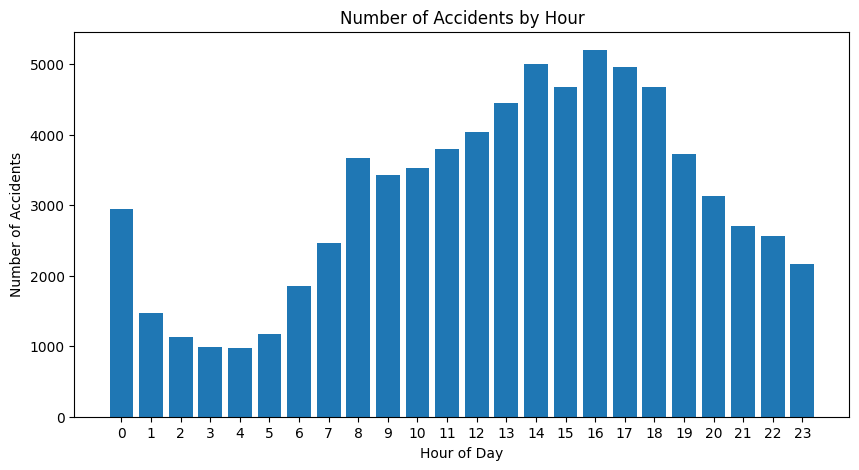

In [127]:
hour_counts = df["HOUR"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(hour_counts.index, hour_counts.values)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.title("Number of Accidents by Hour")

plt.xticks(range(24))

plt.show()

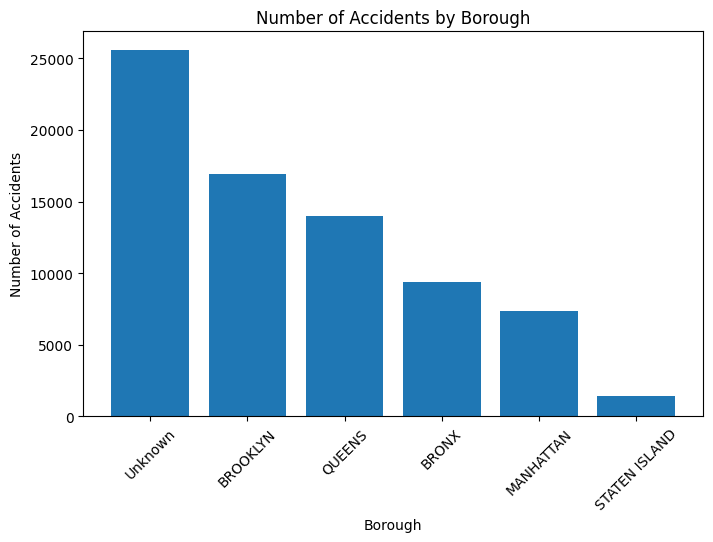

In [128]:
borough_counts = df["BOROUGH"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    borough_counts.index,
    borough_counts.values
)

plt.xlabel("Borough")
plt.ylabel("Number of Accidents")
plt.title("Number of Accidents by Borough")

plt.xticks(rotation=45)

plt.show()

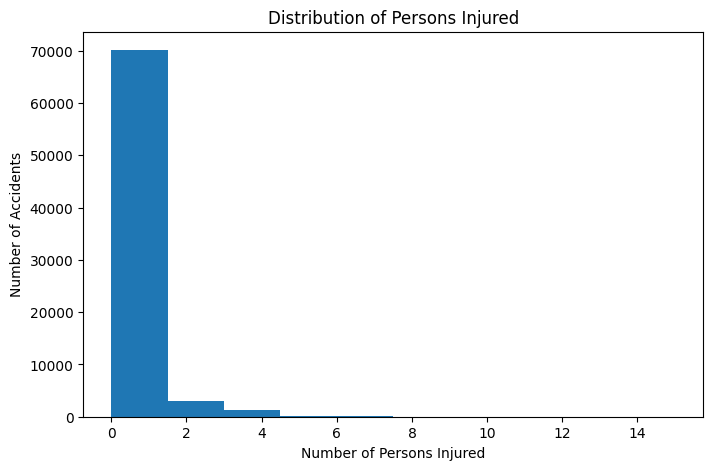

In [129]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["NUMBER OF PERSONS INJURED"],
    bins=10
)

plt.xlabel("Number of Persons Injured")
plt.ylabel("Number of Accidents")
plt.title("Distribution of Persons Injured")

plt.show()

In [131]:
df = pd.get_dummies(
    df,
    columns=["BOROUGH"],
    drop_first=True,
    dtype=int
)

In [132]:
X = df.drop(
    columns=[
        "CRASH DATE",
        "CRASH TIME",
        "NUMBER OF PERSONS INJURED"
    ]
)

y = df["NUMBER OF PERSONS INJURED"]

In [133]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (74682, 12)
y shape: (74682,)


In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (59745, 12)
Testing data: (14937, 12)


In [135]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [136]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr.predict(X_test_scaled)

In [137]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression
-------------------------
MAE : 0.5183500740224585
MSE : 0.5077781397331459
RMSE: 0.712585531521056
R2  : 0.014109534375593036


In [138]:
knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn.predict(X_test_scaled)

In [139]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)

mse_knn = mean_squared_error(y_test, y_pred_knn)

rmse_knn = np.sqrt(mse_knn)

r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression")
print("-------------------------")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R2  :", r2_knn)

KNN Regression
-------------------------
MAE : 0.520907812813818
MSE : 0.6018129477137311
RMSE: 0.775766039288735
R2  : -0.16846630607630564


In [140]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regression"],
    "MAE": [mae_lr, mae_knn],
    "RMSE": [rmse_lr, rmse_knn],
    "R2 Score": [r2_lr, r2_knn]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.518350,0.712586,0.014110
1,KNN Regression,0.520908,0.775766,-0.168466


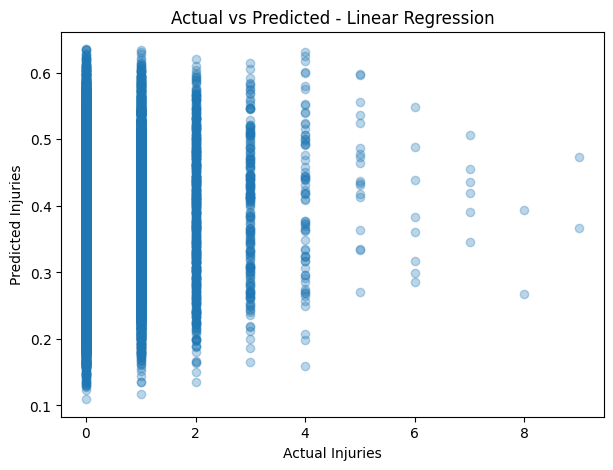

In [141]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_lr, alpha=0.3)

plt.xlabel("Actual Injuries")
plt.ylabel("Predicted Injuries")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

In [142]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

print("Original features:", X_train_scaled.shape[1])
print("PCA features:", X_pca.shape[1])

Original features: 12
PCA features: 2


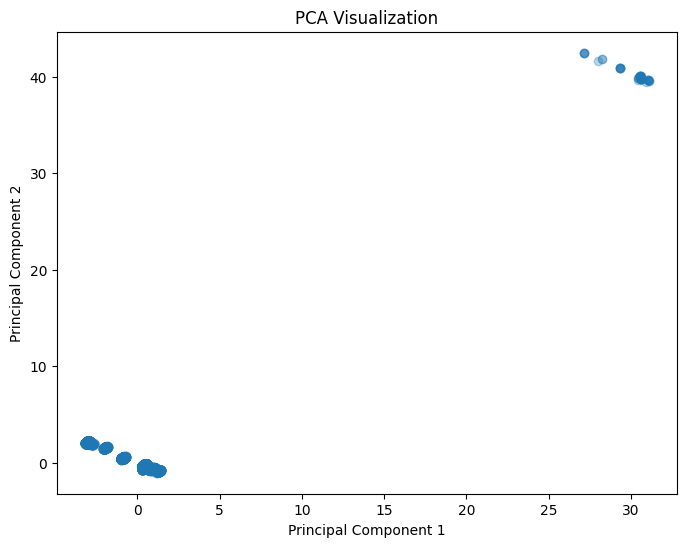

In [143]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.3
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.show()

In [144]:
import joblib

joblib.dump(lr, "accident_injury_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


###Conclusion:

In this project, NYC traffic accident data was analyzed to understand
accident patterns and predict the number of persons injured.

The data was cleaned and important features such as hour, day, month
and day of the week were extracted from the crash date and time.

Linear Regression and KNN Regression were implemented and evaluated
using MAE, RMSE and R² score.

PCA was also used to visualize the data in two dimensions.

The model results provide an understanding of how machine learning
can be applied to traffic accident data.